# Formalization 1 — Dynamic Hierarchical Random Measure

This notebook turns the idea into a measure-theoretic object.

Core interpretation:

A price chart is treated as an observable trace of collective behavior.  
At each time \(t\), the market state is represented by a hierarchy of regions.  
Each region has a probability mass, local features, and optional children.  
The hierarchy may split, merge, fade, or grow over time.

The learning goal is not to assert that "greed" or "fear" are directly visible.
The goal is to build computable indices and test whether those indices improve
prediction or representation learning.

## Mathematical object

Let \(X\) be the feature space of market observations, for example:

\[
X = \mathbb{R}^{d}
\]

A hierarchy at time \(t\) is a rooted tree:

\[
\mathcal{T}_t = (V_t, E_t)
\]

Each node \(v \in V_t\) corresponds to a region \(R_{t,v} \subset X\), a mass
\(\pi_{t,v}\in[0,1]\), and a local probability measure:

\[
\mu_{t,v} \in \mathcal{P}(R_{t,v})
\]

For children \(C(v)\), the local consistency condition is:

\[
\sum_{u\in C(v)} \pi_{t,u} = \pi_{t,v}
\]

The global measure is assembled as:

\[
\mu_t(A) = \sum_{v\in L_t} \pi_{t,v}\mu_{t,v}(A\cap R_{t,v})
\]

where \(L_t\) is the current set of leaves.

Dynamic operations:

\[
\mathcal{T}_{t+1} = \mathsf{Evolve}(\mathcal{T}_t, x_t)
\]

where \(\mathsf{Evolve}\) may include split, merge, pruning, and mass transport.

In [1]:
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch is not available in this environment:", repr(e))

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

In [2]:
def make_synthetic_market_data(n_steps: int = 2500, seed: int = 42) -> pd.DataFrame:
    """
    Synthetic market-like data with latent psychological regimes.

    Regimes:
    0 = calm accumulation
    1 = greedy trend
    2 = fear selloff
    3 = noisy transition

    This is not meant to simulate real markets faithfully.
    It exists so the hierarchy code can run without external data.
    Replace this function with a real OHLCV loader when you have data.
    """
    rng = np.random.default_rng(seed)

    transition = np.array([
        [0.965, 0.020, 0.005, 0.010],
        [0.025, 0.940, 0.015, 0.020],
        [0.025, 0.020, 0.935, 0.020],
        [0.250, 0.250, 0.250, 0.250],
    ])

    drift = np.array([0.00015, 0.00125, -0.00155, 0.00000])
    vol = np.array([0.006, 0.010, 0.017, 0.012])
    volume_mu = np.array([0.0, 0.45, 0.75, 0.25])
    volume_sigma = np.array([0.25, 0.35, 0.45, 0.40])

    regimes = np.zeros(n_steps, dtype=int)
    returns = np.zeros(n_steps)
    volume_z = np.zeros(n_steps)

    regimes[0] = 0
    for t in range(1, n_steps):
        regimes[t] = rng.choice(4, p=transition[regimes[t - 1]])
        r = drift[regimes[t]] + vol[regimes[t]] * rng.standard_normal()

        # Occasional regime-specific impulse.
        if regimes[t] == 1 and rng.random() < 0.020:
            r += abs(rng.normal(0.018, 0.007))
        if regimes[t] == 2 and rng.random() < 0.030:
            r -= abs(rng.normal(0.026, 0.010))

        returns[t] = r
        volume_z[t] = rng.normal(volume_mu[regimes[t]], volume_sigma[regimes[t]])

    price = 100.0 * np.exp(np.cumsum(returns))
    volume = np.exp(volume_z) * 1_000_000

    df = pd.DataFrame({
        "t": np.arange(n_steps),
        "close": price,
        "return": returns,
        "volume": volume,
        "latent_regime": regimes,
    })

    df["future_return_5"] = df["close"].shift(-5) / df["close"] - 1.0
    df["target_up_5"] = (df["future_return_5"] > 0).astype(int)
    df = df.dropna().reset_index(drop=True)
    return df

df = make_synthetic_market_data()
df.head()

,t,close,return,volume,latent_regime,future_return_5,target_up_5
0,0,100.000000,0.000000,1.000000e+06,0,-0.007029,0
1,1,99.392860,-0.006090,1.206366e+06,0,0.001400,1
2,2,98.250867,-0.011556,7.221338e+05,0,0.012888,1
3,3,98.079327,-0.001747,9.958085e+05,0,0.022283,1
4,4,98.612991,0.005426,1.214640e+06,0,0.014757,1


In [3]:
def rolling_zscore(x: pd.Series, window: int, eps: float = 1e-8) -> pd.Series:
    mean = x.rolling(window, min_periods=window // 2).mean()
    std = x.rolling(window, min_periods=window // 2).std()
    return (x - mean) / (std + eps)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def make_market_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["ret_1"] = out["close"].pct_change().fillna(0.0)
    out["ret_5"] = out["close"].pct_change(5).fillna(0.0)
    out["ret_20"] = out["close"].pct_change(20).fillna(0.0)
    out["vol_10"] = out["ret_1"].rolling(10, min_periods=5).std().fillna(0.0)
    out["vol_30"] = out["ret_1"].rolling(30, min_periods=10).std().fillna(0.0)
    out["volume_z_20"] = rolling_zscore(np.log(out["volume"]), 20).fillna(0.0)
    out["drawdown_30"] = out["close"] / out["close"].rolling(30, min_periods=10).max() - 1.0
    out["trend_pressure"] = rolling_zscore(out["ret_5"], 30).fillna(0.0)
    out["fear_pressure"] = (-3.0 * out["drawdown_30"] + 2.0 * out["vol_10"] + 0.40 * out["volume_z_20"])
    out["greed_pressure"] = (2.5 * out["ret_20"] + 1.0 * out["trend_pressure"] + 0.25 * out["volume_z_20"])
    out["fear_index"] = sigmoid_np(out["fear_pressure"].clip(-8, 8))
    out["greed_index"] = sigmoid_np(out["greed_pressure"].clip(-8, 8))
    return out.fillna(0.0)

features_df = make_market_features(df)
features_df[["t", "close", "ret_5", "ret_20", "vol_10", "volume_z_20", "fear_index", "greed_index", "target_up_5"]].head()

,t,close,ret_5,ret_20,vol_10,volume_z_20,fear_index,greed_index,target_up_5
0,0,100.000000,0.0,0.0,0.000000,0.0,0.0,0.5,0
1,1,99.392860,0.0,0.0,0.000000,0.0,0.0,0.5,1
2,2,98.250867,0.0,0.0,0.000000,0.0,0.0,0.5,1
3,3,98.079327,0.0,0.0,0.000000,0.0,0.0,0.5,1
4,4,98.612991,0.0,0.0,0.006385,0.0,0.0,0.5,1


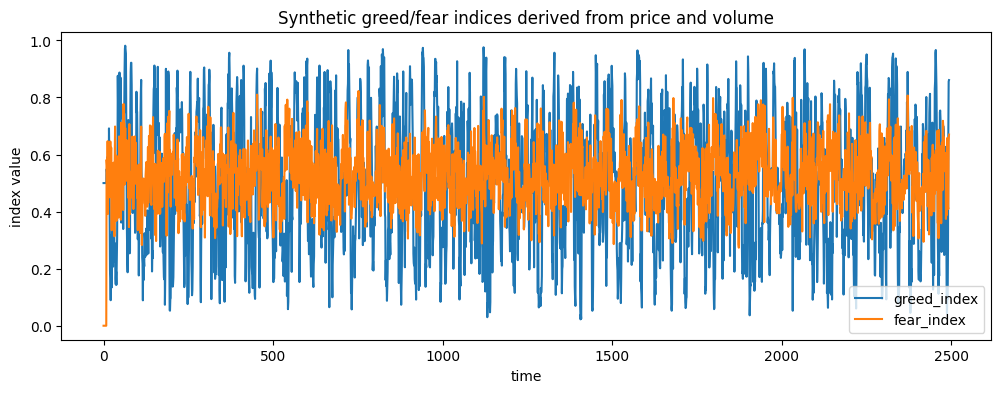

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(features_df["t"], features_df["greed_index"], label="greed_index")
plt.plot(features_df["t"], features_df["fear_index"], label="fear_index")
plt.xlabel("time")
plt.ylabel("index value")
plt.legend()
plt.title("Synthetic greed/fear indices derived from price and volume")
plt.show()

## A minimal dynamic hierarchy implementation

We build a binary hierarchy over two psychological axes:

- greed index
- fear index

The hierarchy is not hard-coded as a final truth. It is a computable instrument:
it partitions the observable space into interpretable regions.

In [5]:
@dataclass
class MeasureNode:
    node_id: str
    depth: int
    bounds: Dict[str, Tuple[float, float]]
    mass: float
    count: int
    mean: Dict[str, float]
    children: Optional[List["MeasureNode"]] = None

    @property
    def is_leaf(self) -> bool:
        return not self.children

def in_bounds(row: pd.Series, bounds: Dict[str, Tuple[float, float]]) -> bool:
    for col, (lo, hi) in bounds.items():
        value = float(row[col])
        if not (lo <= value < hi):
            return False
    return True

def split_node(node: MeasureNode, split_col: str, split_value: float) -> List[MeasureNode]:
    lo, hi = node.bounds[split_col]
    left_bounds = dict(node.bounds)
    right_bounds = dict(node.bounds)
    left_bounds[split_col] = (lo, split_value)
    right_bounds[split_col] = (split_value, hi)

    left = MeasureNode(
        node_id=node.node_id + "L",
        depth=node.depth + 1,
        bounds=left_bounds,
        mass=node.mass / 2.0,
        count=0,
        mean={},
        children=None,
    )
    right = MeasureNode(
        node_id=node.node_id + "R",
        depth=node.depth + 1,
        bounds=right_bounds,
        mass=node.mass / 2.0,
        count=0,
        mean={},
        children=None,
    )
    node.children = [left, right]
    return node.children

def collect_leaves(node: MeasureNode) -> List[MeasureNode]:
    if node.is_leaf:
        return [node]
    leaves = []
    for child in node.children:
        leaves.extend(collect_leaves(child))
    return leaves

def build_static_hierarchy(df: pd.DataFrame, max_depth: int = 3, min_count: int = 80) -> MeasureNode:
    feature_cols = ["greed_index", "fear_index"]
    root = MeasureNode(
        node_id="root",
        depth=0,
        bounds={"greed_index": (0.0, 1.000001), "fear_index": (0.0, 1.000001)},
        mass=1.0,
        count=len(df),
        mean={col: float(df[col].mean()) for col in feature_cols},
        children=None,
    )

    queue = [root]
    while queue:
        node = queue.pop(0)
        if node.depth >= max_depth:
            continue

        mask = df.apply(lambda row: in_bounds(row, node.bounds), axis=1)
        subset = df[mask]
        node.count = len(subset)
        node.mass = node.count / max(len(df), 1)
        if node.count < min_count:
            continue

        variances = {col: float(subset[col].var()) for col in feature_cols}
        split_col = max(variances, key=variances.get)
        split_value = float(subset[split_col].median())

        if node.bounds[split_col][0] < split_value < node.bounds[split_col][1]:
            children = split_node(node, split_col, split_value)
            queue.extend(children)

    for leaf in collect_leaves(root):
        mask = df.apply(lambda row: in_bounds(row, leaf.bounds), axis=1)
        subset = df[mask]
        leaf.count = len(subset)
        leaf.mass = leaf.count / max(len(df), 1)
        leaf.mean = {col: float(subset[col].mean()) if len(subset) else 0.0 for col in feature_cols}

    return root

root = build_static_hierarchy(features_df, max_depth=4, min_count=100)
leaves = collect_leaves(root)

summary = pd.DataFrame([{
    "node_id": leaf.node_id,
    "depth": leaf.depth,
    "mass": leaf.mass,
    "count": leaf.count,
    "greed_range": leaf.bounds["greed_index"],
    "fear_range": leaf.bounds["fear_index"],
    "mean_greed": leaf.mean["greed_index"],
    "mean_fear": leaf.mean["fear_index"],
} for leaf in leaves])

summary.sort_values("mass", ascending=False).head(20)

,node_id,depth,mass,count,greed_range,fear_range,mean_greed,mean_fear
1,rootLLLR,4,0.062525,156,"(0.2199806204486056, 0.31752804249575706)","(0.0, 0.5172060322269186)",0.267940,0.441056
2,rootLLRL,4,0.062525,156,"(0.0, 0.2132188476865567)","(0.5172060322269186, 1.000001)",0.136587,0.607794
3,rootLLRR,4,0.062525,156,"(0.2132188476865567, 0.31752804249575706)","(0.5172060322269186, 1.000001)",0.267362,0.602582
4,rootLRLL,4,0.062525,156,"(0.31752804249575706, 0.5011826947145956)","(0.0, 0.4298408578580225)",0.416826,0.362781
5,rootLRLR,4,0.062525,156,"(0.31752804249575706, 0.5011826947145956)","(0.4298408578580225, 0.5057360965931733)",0.409815,0.467100
6,rootLRRL,4,0.062525,156,"(0.31752804249575706, 0.5011826947145956)","(0.5057360965931733, 0.5799526744578538)",0.405620,0.541392
7,rootLRRR,4,0.062525,156,"(0.31752804249575706, 0.5011826947145956)","(0.5799526744578538, 1.000001)",0.402276,0.640326
8,rootRLLL,4,0.062525,156,"(0.5011826947145956, 0.6911521015897403)","(0.0, 0.4531948246469102)",0.589957,0.400024
9,rootRLLR,4,0.062525,156,"(0.5011826947145956, 0.6911521015897403)","(0.4531948246469102, 0.5231535741979918)",0.593314,0.489167
10,rootRLRL,4,0.062525,156,"(0.5011826947145956, 0.6911521015897403)","(0.5231535741979918, 0.5943481185826789)",0.596745,0.556353


## Convert hierarchy leaves into learnable features

For each time point, we compute a soft membership vector over hierarchy leaves.
This vector becomes a model input.

In [6]:
def soft_membership(row: pd.Series, leaves: List[MeasureNode], temperature: float = 0.05) -> np.ndarray:
    point = np.array([float(row["greed_index"]), float(row["fear_index"])])
    centers = []
    for leaf in leaves:
        g_lo, g_hi = leaf.bounds["greed_index"]
        f_lo, f_hi = leaf.bounds["fear_index"]
        centers.append([(g_lo + g_hi) / 2.0, (f_lo + f_hi) / 2.0])
    centers = np.array(centers)

    distances = np.sum((centers - point[None, :]) ** 2, axis=1)
    logits = -distances / max(temperature, 1e-6)
    logits = logits - logits.max()
    weights = np.exp(logits)
    weights = weights / weights.sum()
    return weights

membership_matrix = np.vstack([
    soft_membership(row, leaves)
    for _, row in features_df.iterrows()
])

membership_columns = [f"leaf_{leaf.node_id}" for leaf in leaves]
membership_df = pd.DataFrame(membership_matrix, columns=membership_columns)
model_df = pd.concat([features_df.reset_index(drop=True), membership_df], axis=1)

model_df[membership_columns + ["target_up_5"]].head()

,leaf_rootLLLL,leaf_rootLLLR,leaf_rootLLRL,leaf_rootLLRR,leaf_rootLRLL,leaf_rootLRLR,leaf_rootLRRL,leaf_rootLRRR,leaf_rootRLLL,leaf_rootRLLR,leaf_rootRLRL,leaf_rootRLRR,leaf_rootRRLL,leaf_rootRRLR,leaf_rootRRRL,leaf_rootRRRR,target_up_5
0,0.015033,0.10808,5.449421e-07,0.000004,0.404129,0.012795,0.002807,0.000004,0.35709,0.008488,0.001936,0.000003,0.078657,0.010973,0.000002,2.570098e-07,0
1,0.015033,0.10808,5.449421e-07,0.000004,0.404129,0.012795,0.002807,0.000004,0.35709,0.008488,0.001936,0.000003,0.078657,0.010973,0.000002,2.570098e-07,1
2,0.015033,0.10808,5.449421e-07,0.000004,0.404129,0.012795,0.002807,0.000004,0.35709,0.008488,0.001936,0.000003,0.078657,0.010973,0.000002,2.570098e-07,1
3,0.015033,0.10808,5.449421e-07,0.000004,0.404129,0.012795,0.002807,0.000004,0.35709,0.008488,0.001936,0.000003,0.078657,0.010973,0.000002,2.570098e-07,1
4,0.015033,0.10808,5.449421e-07,0.000004,0.404129,0.012795,0.002807,0.000004,0.35709,0.008488,0.001936,0.000003,0.078657,0.010973,0.000002,2.570098e-07,1


## Train a baseline model and a hierarchy-augmented model

We compare:

1. baseline price-derived features
2. baseline features + hierarchy membership features

In [7]:
if not TORCH_AVAILABLE:
    raise RuntimeError("This training section requires PyTorch.")

class TabularDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, feature_columns: List[str], target_column: str):
        self.x = frame[feature_columns].astype("float32").to_numpy()
        self.y = frame[target_column].astype("int64").to_numpy()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return torch.tensor(self.x[idx]), torch.tensor(self.y[idx])

def time_split(frame: pd.DataFrame, train_frac: float = 0.70, val_frac: float = 0.15):
    n = len(frame)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return frame.iloc[:train_end], frame.iloc[train_end:val_end], frame.iloc[val_end:]

class MLPClassifier(nn.Module):
    def __init__(self, n_features: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x):
        return self.net(x)

def train_classifier(train_df, val_df, feature_columns, target_column="target_up_5", epochs=25):
    train_loader = DataLoader(TabularDataset(train_df, feature_columns, target_column), batch_size=64, shuffle=True)
    val_loader = DataLoader(TabularDataset(val_df, feature_columns, target_column), batch_size=256, shuffle=False)

    model = MLPClassifier(n_features=len(feature_columns))
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += float(loss.item()) * len(xb)

        model.eval()
        correct = 0
        total = 0
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)
                val_loss += float(loss.item()) * len(xb)
                pred = logits.argmax(dim=1)
                correct += int((pred == yb).sum().item())
                total += len(xb)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss / len(train_df),
            "val_loss": val_loss / len(val_df),
            "val_accuracy": correct / max(total, 1),
        })

    return model, pd.DataFrame(history)

train_df, val_df, test_df = time_split(model_df)

base_cols = ["ret_1", "ret_5", "ret_20", "vol_10", "vol_30", "volume_z_20", "drawdown_30"]
hier_cols = base_cols + ["greed_index", "fear_index"] + membership_columns

baseline_model, baseline_history = train_classifier(train_df, val_df, base_cols)
hier_model, hier_history = train_classifier(train_df, val_df, hier_cols)

pd.concat([
    baseline_history.assign(model="baseline"),
    hier_history.assign(model="hierarchy_augmented")
]).tail(10)

,epoch,train_loss,val_loss,val_accuracy,model
15,16,0.674512,0.687617,0.545455,hierarchy_augmented
16,17,0.673228,0.690214,0.550802,hierarchy_augmented
17,18,0.674267,0.686274,0.553476,hierarchy_augmented
18,19,0.671343,0.687857,0.550802,hierarchy_augmented
19,20,0.669909,0.690194,0.550802,hierarchy_augmented
20,21,0.671480,0.688972,0.548128,hierarchy_augmented
21,22,0.670703,0.687904,0.542781,hierarchy_augmented
22,23,0.672295,0.688454,0.545455,hierarchy_augmented
23,24,0.669337,0.690603,0.553476,hierarchy_augmented
24,25,0.671181,0.689832,0.545455,hierarchy_augmented


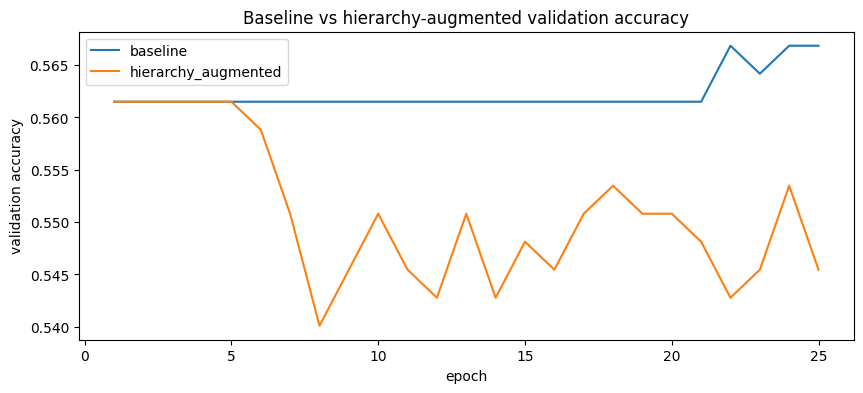

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(baseline_history["epoch"], baseline_history["val_accuracy"], label="baseline")
plt.plot(hier_history["epoch"], hier_history["val_accuracy"], label="hierarchy_augmented")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Baseline vs hierarchy-augmented validation accuracy")
plt.legend()
plt.show()

## Interpretation protocol

This formalization is useful if:

- hierarchy membership features improve out-of-sample performance;
- learned node masses correlate with meaningful market states;
- node splitting/merging remains stable under time-respecting validation;
- greedy/fearful regions do not merely overfit future labels.

The scientific claim should be restricted:

> Under this feature construction and time split, hierarchy-derived market-state features provide or fail to provide additional predictive information beyond ordinary price/volume features.